# TwoNN Benchmark + CIP Analysis


**Goals:**
1. Validate TwoNN as a reliable ID estimator for galaxy embedding spaces (Sections 1–5)
2. Show TwoNN + linear probe is needed together — neither alone is sufficient (Section 3)
3. Fix layerwise synthetic sim to produce realistic Ansuini compression profile (Section 7)
4. Introduce Causal Inner Product (CIP) to challenge paper Fig. 3 cosine similarity (Section 9)
5. Load real precomputed embeddings from UniverseTBD HuggingFace and run CIP on actual data (Section 10)

**Key claim:** The paper's cosine similarity between probe directions (Fig. 3) cannot distinguish genuine
representational entanglement from Malmquist selection artifacts. CIP on counterfactual pairs can.

In [1]:
import sys
!{sys.executable} -m pip install scikit-dimension datasets huggingface_hub -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import skdim.id as sid
import skdim.datasets as skd
from dataclasses import dataclass, field
from typing import Optional, Union
from scipy.stats import ortho_group
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# ── Synthetic data generators ──────────────────────────────────────────────
@dataclass
class SyntheticDataset:
    name: str
    X: np.ndarray
    id_true: Union[int, dict]
    y: Optional[np.ndarray] = None
    labels: Optional[np.ndarray] = None
    meta: dict = field(default_factory=dict)
    @property
    def n(self): return self.X.shape[0]
    @property
    def ambient_dim(self): return self.X.shape[1]

def _rng(seed): return np.random.default_rng(seed)
def _haar(D, rng): return ortho_group.rvs(D, random_state=int(rng.integers(2**31-1)))

def embed_ambient(X, D, rng):
    if D is None: return X
    n, d0 = X.shape
    Xp = np.zeros((n, D)); Xp[:, :d0] = X
    return Xp @ _haar(D, rng).T

def add_isotropic_noise(X, snr, rng):
    if snr is None or np.isinf(snr): return X, 0.0
    D = X.shape[1]
    signal_power = float(np.mean(np.sum((X - X.mean(0))**2, 1)))
    sigma = float(np.sqrt(signal_power / (snr * D)))
    return X + rng.normal(0., sigma, size=X.shape), sigma

def iso_gaussian(n, D, seed=None):
    rng = _rng(seed)
    return SyntheticDataset('iso_gaussian', rng.normal(size=(n, D)), D, meta=dict(seed=seed))

def aniso_gaussian(n, D, alpha=1.0, seed=None):
    rng = _rng(seed)
    lam = np.arange(1, D+1, dtype=float)**(-alpha)
    X = rng.normal(size=(n, D)) * np.sqrt(lam)
    X = X @ _haar(D, rng).T
    return SyntheticDataset('aniso_gaussian', X, D, meta=dict(seed=seed, alpha=alpha))

def swiss_roll(n, D=None, seed=None):
    rng = _rng(seed)
    X3 = skd.swissRoll3Sph(n, 0, random_state=int(rng.integers(2**31-1)))[:, :3]
    X = embed_ambient(X3, D, rng)
    return SyntheticDataset('swiss_roll', X, 2, meta=dict(seed=seed))

def hyper_twin_peaks(n, intrinsic_dim=2, D=None, seed=None):
    rng = _rng(seed)
    Xk = skd.hyperTwinPeaks(n, d=intrinsic_dim, random_state=int(rng.integers(2**31-1)))
    X = embed_ambient(Xk, D, rng)
    return SyntheticDataset('hyper_twin_peaks', X, intrinsic_dim, meta=dict(seed=seed))

def planted_manifold(n, intrinsic_dim, D, n_lift=None, lift_scale=0.5, seed=None):
    rng = _rng(seed); k = intrinsic_dim
    if n_lift is None: n_lift = max(2, k // 2)
    u = skd.hyperBall(n, d=k, radius=1.0, random_state=int(rng.integers(2**31-1)))
    A = rng.normal(size=(n_lift, k, k))
    A = (A + np.transpose(A, (0,2,1))) / 2.
    z = lift_scale * np.einsum('ni,mij,nj->nm', u, A, u)
    low = np.concatenate([u, z], axis=1)
    X = embed_ambient(low, D, rng)
    return SyntheticDataset('planted_manifold', X, k, meta=dict(seed=seed))

def planted_manifold_noisy(n, intrinsic_dim, D, snr, seed=None):
    clean = planted_manifold(n, intrinsic_dim, D, seed=seed)
    rng = _rng(None if seed is None else seed+1)
    X, sigma = add_isotropic_noise(clean.X, snr, rng)
    return SyntheticDataset('planted_manifold_noisy', X, intrinsic_dim, meta=dict(snr=snr, sigma=sigma))

def swiss_roll_3sphere(n_roll, n_sphere, D=None, seed=None):
    rng = _rng(seed)
    X4 = skd.swissRoll3Sph(n_roll, n_sphere, random_state=int(rng.integers(2**31-1)))
    labels = np.concatenate([np.zeros(n_roll, dtype=int), np.ones(n_sphere, dtype=int)])
    X = embed_ambient(X4, D, rng)
    return SyntheticDataset('swiss_roll_3sphere', X, {'swiss_roll': 2, 'sphere3': 3}, labels=labels, meta=dict(seed=seed))

# ── Estimator helpers ──────────────────────────────────────────────────────
ESTIMATORS = {'TwoNN': sid.TwoNN(), 'MLE': sid.MLE(), 'lPCA': sid.lPCA(), 'CorrInt': sid.CorrInt()}

def estimate_id(X, estimators=ESTIMATORS):
    results = {}
    for name, est in estimators.items():
        try:
            results[name] = round(float(est.__class__().fit(X).dimension_), 2)
        except Exception as e:
            results[name] = np.nan; print(f'  [{name}] failed: {e}')
    return results

def run_and_record(ds, label=None):
    id_true = ds.id_true if isinstance(ds.id_true, int) else str(ds.id_true)
    ests = estimate_id(ds.X)
    row = {'dataset': label or ds.name, 'id_true': id_true, 'n': ds.n, 'D': ds.ambient_dim}
    row.update(ests)
    if isinstance(ds.id_true, int):
        row['TwoNN_err'] = round(ests['TwoNN'] - ds.id_true, 2)
    return row

print('imports ok')

c:\Users\dunli\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


imports ok


## 1. Null distributions
ID_true = D (ambient). TwoNN should return ~D, not something smaller.

**What to look for:** TwoNN should approach `id_true = D = 20` for iso_gaussian. Underestimation in aniso_gaussian (high α) is a known limitation — covariance shape bleeds into NN distances at finite n.

In [3]:
N, D_null = 800, 20

null_rows = []
for ds in [
    iso_gaussian(N, D_null, seed=0),
    aniso_gaussian(N, D_null, alpha=1.0, seed=0),
    aniso_gaussian(N, D_null, alpha=2.0, seed=0),
]:
    print(f'running {ds.name} ...')
    null_rows.append(run_and_record(ds))

df_null = pd.DataFrame(null_rows)
print('\n--- Null distributions ---')
display(df_null)

running iso_gaussian ...
running aniso_gaussian ...
running aniso_gaussian ...

--- Null distributions ---


,dataset,id_true,n,D,TwoNN,MLE,lPCA,CorrInt,TwoNN_err
0,iso_gaussian,20,800,20,16.80,14.42,20.0,11.46,-3.20
1,aniso_gaussian,20,800,20,14.86,12.12,19.0,9.96,-5.14
2,aniso_gaussian,20,800,20,10.61,8.35,4.0,6.93,-9.39


## 2. Clean manifolds — known ID recovery

Checks TwoNN against ground-truth manifold dimension embedded in R^50. Error < 1 unit for k ≤ 10 is acceptable for galaxy embedding analysis.

In [4]:
N_man = 1000
D_embed = 50

manifold_datasets = [
    swiss_roll(N_man, seed=0),
    swiss_roll(N_man, D=D_embed, seed=0),
    hyper_twin_peaks(N_man, intrinsic_dim=3, seed=0),
    hyper_twin_peaks(N_man, intrinsic_dim=5, D=D_embed, seed=0),
    planted_manifold(N_man, 4, D_embed, seed=0),
    planted_manifold(N_man, 8, D_embed, seed=0),
    planted_manifold(N_man, 16, D_embed, seed=0),
]

man_rows = []
for ds in manifold_datasets:
    label = f"{ds.name}_k{ds.id_true}_D{ds.ambient_dim}"
    print(f'running {label} ...')
    man_rows.append(run_and_record(ds, label=label))

df_man = pd.DataFrame(man_rows)
print('\n--- Clean manifolds ---')
display(df_man)

running swiss_roll_k2_D3 ...
running swiss_roll_k2_D50 ...
running hyper_twin_peaks_k3_D4 ...
running hyper_twin_peaks_k5_D50 ...
running planted_manifold_k4_D50 ...
running planted_manifold_k8_D50 ...
running planted_manifold_k16_D50 ...

--- Clean manifolds ---


,dataset,id_true,n,D,TwoNN,MLE,lPCA,CorrInt,TwoNN_err
0,swiss_roll_k2_D3,2,1000,3,1.92,1.96,3.0,1.93,-0.08
1,swiss_roll_k2_D50,2,1000,50,1.92,1.96,3.0,1.93,-0.08
2,hyper_twin_peaks_k3_D4,3,1000,4,2.89,2.81,4.0,2.82,-0.11
3,hyper_twin_peaks_k5_D50,5,1000,50,4.85,4.60,6.0,4.61,-0.15
4,planted_manifold_k4_D50,4,1000,50,4.07,3.78,6.0,3.84,0.07
5,planted_manifold_k8_D50,8,1000,50,7.71,7.07,12.0,6.99,-0.29
6,planted_manifold_k16_D50,16,1000,50,12.27,12.01,24.0,11.26,-3.73


k= 2  TwoNN=2.0  MLE=1.9
k= 4  TwoNN=3.6  MLE=3.8
k= 6  TwoNN=5.7  MLE=5.5
k= 8  TwoNN=7.7  MLE=7.0
k=10  TwoNN=9.5  MLE=8.5
k=12  TwoNN=9.7  MLE=9.7
k=16  TwoNN=13.0  MLE=12.3


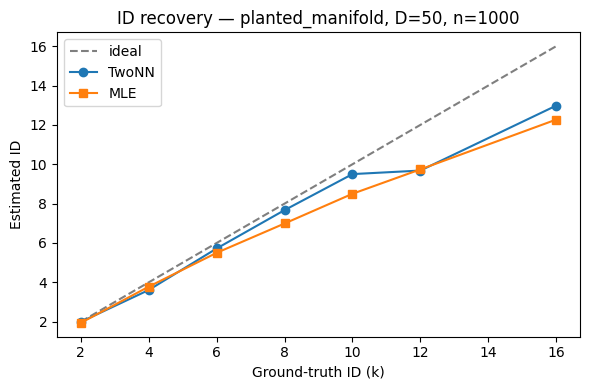

In [5]:
# Power curve: TwoNN estimated ID vs ground-truth across planted_manifold sweep
ks = [2, 4, 6, 8, 10, 12, 16]
twonn_sweep, mle_sweep = [], []

for k in ks:
    ds = planted_manifold(N_man, k, D_embed, seed=42)
    ests = estimate_id(ds.X)
    twonn_sweep.append(ests['TwoNN']); mle_sweep.append(ests['MLE'])
    print(f'k={k:2d}  TwoNN={ests["TwoNN"]:.1f}  MLE={ests["MLE"]:.1f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, ks, 'k--', label='ideal', alpha=0.5)
ax.plot(ks, twonn_sweep, 'o-', label='TwoNN')
ax.plot(ks, mle_sweep, 's-', label='MLE')
ax.set_xlabel('Ground-truth ID (k)'); ax.set_ylabel('Estimated ID')
ax.set_title(f'ID recovery — planted_manifold, D={D_embed}, n={N_man}')
ax.legend(); plt.tight_layout(); plt.savefig('id_power_curve.png', dpi=150); plt.show()

## 3. TwoNN + Linear Probe — why you need both

Both linear and nonlinear modes have the same ID (~9). TwoNN alone cannot distinguish them.
A linear probe R² gap is what separates a linearly-encoded direction from a curved manifold.

**This directly motivates the paper extension:** the paper's cosine similarity measures angle
between probe weight vectors, but if the direction is curved in embedding space, cosine is
measuring manifold geometry not linear separability.

In [6]:
def _curved_centerline(a, b, nturn, scale):
    def gamma(t):
        th = 2.*np.pi*nturn*t; r = scale*(a + b*t)
        return np.stack([r*np.cos(th), r*np.sin(th)], axis=-1)
    return gamma

def _arclength_reparam(gamma, n_grid=20001):
    t_grid = np.linspace(0., 1., n_grid); pts = gamma(t_grid)
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    cum = np.concatenate([[0.], np.cumsum(seg)]); s_grid = cum / cum[-1]
    return lambda s: np.interp(s, s_grid, t_grid), float(cum[-1])

def planted_quantity(n, D, mode='linear', m_nuisance=8, tube_width=0.25,
                     snr=None, nturn=1.5, curve_scale=1.0, seed=None):
    rng = _rng(seed); s = rng.uniform(0., 1., size=n)
    u = rng.uniform(-1., 1., size=(n, m_nuisance)) * tube_width
    if mode == 'linear':
        low = np.concatenate([(s*curve_scale)[:,None], u], axis=1)
    else:
        gamma = _curved_centerline(1., 1., nturn, curve_scale)
        t_of_s, _ = _arclength_reparam(gamma)
        center = gamma(t_of_s(s))
        low = np.concatenate([center, u], axis=1)
    X = embed_ambient(low, D, rng); X, _ = add_isotropic_noise(X, snr, rng)
    return SyntheticDataset('planted_quantity', X, 1+m_nuisance, y=s, meta=dict(mode=mode, seed=seed))

N_pq, D_pq = 1000, 50
pq_lin    = planted_quantity(N_pq, D_pq, mode='linear',    nturn=1.5, seed=0)
pq_nonlin = planted_quantity(N_pq, D_pq, mode='nonlinear', nturn=1.5, seed=0)
pq_hard   = planted_quantity(N_pq, D_pq, mode='nonlinear', nturn=4.0, seed=0)

probe_results = []
for ds, label in [(pq_lin, 'linear'), (pq_nonlin, 'nonlinear nturn=1.5'), (pq_hard, 'nonlinear nturn=4.0')]:
    ests = estimate_id(ds.X)
    r2 = cross_val_score(Ridge(), ds.X, ds.y, cv=5, scoring='r2').mean()
    probe_results.append({
        'mode': label, 'id_true': ds.id_true,
        'TwoNN': ests['TwoNN'], 'MLE': ests['MLE'],
        'linear_probe_R2': round(r2, 3),
        'expected_R2': '~1.0' if 'linear' in label else '<<1',
    })
    print(f"{label}: TwoNN={ests['TwoNN']}, R²={r2:.3f}")

display(pd.DataFrame(probe_results))
print('\nTwoNN returns same ID for all modes — linear probe R2 gap is the key signal.')

linear: TwoNN=7.26, R²=1.000
nonlinear nturn=1.5: TwoNN=7.03, R²=0.105
nonlinear nturn=4.0: TwoNN=8.24, R²=0.004


,mode,id_true,TwoNN,MLE,linear_probe_R2,expected_R2
0,linear,9,7.26,7.16,1.000,~1.0
1,nonlinear nturn=1.5,9,7.03,6.15,0.105,~1.0
2,nonlinear nturn=4.0,9,8.24,6.74,0.004,~1.0



TwoNN returns same ID for all modes — linear probe R2 gap is the key signal.


## 4. Noisy manifold — SNR threshold

At what signal-to-noise ratio does TwoNN break? Reliable down to SNR ~10–30 for moderate k/D. Below that it inflates toward ambient D. Foundation model embeddings are typically high SNR so this should not be a concern in practice.

SNR=inf    sigma=0.0000  TwoNN=3.9  MLE=3.8
SNR=100    sigma=0.0163  TwoNN=5.5  MLE=4.2
SNR=30     sigma=0.0297  TwoNN=7.5  MLE=5.0
SNR=10     sigma=0.0515  TwoNN=10.5  MLE=6.8
SNR=5      sigma=0.0728  TwoNN=13.8  MLE=8.8
SNR=3      sigma=0.0939  TwoNN=16.6  MLE=10.7
SNR=1      sigma=0.1627  TwoNN=19.3  MLE=14.7


,SNR,id_true,D,TwoNN,MLE,sigma
0,inf,4,30,3.94,3.81,0.0000
1,100.0,4,30,5.48,4.21,0.0163
2,30.0,4,30,7.46,4.99,0.0297
3,10.0,4,30,10.50,6.80,0.0515
4,5.0,4,30,13.83,8.81,0.0728
5,3.0,4,30,16.61,10.70,0.0939
6,1.0,4,30,19.32,14.66,0.1627


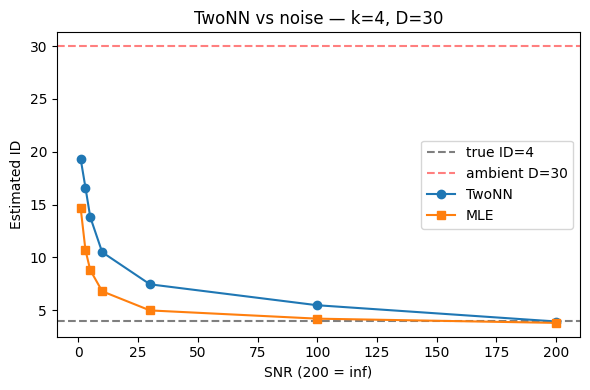

In [7]:
K_noisy, D_noisy = 4, 30
snrs = [np.inf, 100, 30, 10, 5, 3, 1]

snr_rows = []
for snr in snrs:
    ds = planted_manifold_noisy(800, K_noisy, D_noisy, snr=snr, seed=0)
    ests = estimate_id(ds.X)
    snr_rows.append({'SNR': snr, 'id_true': K_noisy, 'D': D_noisy,
                     'TwoNN': ests['TwoNN'], 'MLE': ests['MLE'],
                     'sigma': round(ds.meta['sigma'], 4)})
    print(f"SNR={str(snr):5s}  sigma={ds.meta['sigma']:.4f}  TwoNN={ests['TwoNN']:.1f}  MLE={ests['MLE']:.1f}")

df_snr = pd.DataFrame(snr_rows)
display(df_snr)

fig, ax = plt.subplots(figsize=(6, 4))
snr_plot = [s if not np.isinf(s) else 200 for s in snrs]
ax.axhline(K_noisy, color='k', linestyle='--', label=f'true ID={K_noisy}', alpha=0.5)
ax.axhline(D_noisy, color='r', linestyle='--', label=f'ambient D={D_noisy}', alpha=0.5)
ax.plot(snr_plot, df_snr['TwoNN'], 'o-', label='TwoNN')
ax.plot(snr_plot, df_snr['MLE'], 's-', label='MLE')
ax.set_xlabel('SNR (200 = inf)'); ax.set_ylabel('Estimated ID')
ax.set_title(f'TwoNN vs noise — k={K_noisy}, D={D_noisy}')
ax.legend(); plt.tight_layout(); plt.savefig('id_vs_snr.png', dpi=150); plt.show()

## 5. Heterogeneous — mixed populations

Global TwoNN on a mixed swiss roll (ID=2) + 3-sphere (ID=3) population returns a blended number that represents neither. Relevant for galaxy analysis: star-forming vs quiescent populations may have different intrinsic dimensions.

In [8]:
het = swiss_roll_3sphere(500, 500, seed=0)
global_ests = estimate_id(het.X)
print('Global estimates:', global_ests)
print('True IDs:', het.id_true)

est = sid.TwoNN().fit(het.X)
if hasattr(est, 'distance_ratio_'):
    mu = est.distance_ratio_
    local_id = 1.0 / (np.log(mu) + 1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(local_id[het.labels==0], bins=40, alpha=0.7, label='swiss roll (ID=2)', density=True)
    axes[0].hist(local_id[het.labels==1], bins=40, alpha=0.7, label='3-sphere (ID=3)', density=True)
    axes[0].axvline(2, color='blue', linestyle='--', alpha=0.5)
    axes[0].axvline(3, color='orange', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('local ID estimate'); axes[0].set_title('Pointwise TwoNN by population')
    axes[0].legend()
    axes[1].hist(local_id, bins=60, density=True, color='gray')
    axes[1].set_xlabel('local ID estimate'); axes[1].set_title('Overall (should be bimodal)')
    plt.tight_layout(); plt.savefig('het_local_id.png', dpi=150); plt.show()
else:
    print('distance_ratio_ not available — using global only')
    print(f'Global TwoNN={global_ests["TwoNN"]} sits between true IDs 2 and 3 — misleading for mixed populations')

Global estimates: {'TwoNN': 2.67, 'MLE': 2.63, 'lPCA': 3.0, 'CorrInt': 3.13}
True IDs: {'swiss_roll': 2, 'sphere3': 3}
distance_ratio_ not available — using global only
Global TwoNN=2.67 sits between true IDs 2 and 3 — misleading for mixed populations


## 6. Summary table — TwoNN validation

Consolidates Sections 1–5 into a single reference table. TwoNN is validated as reliable for k ≤ 10 in D=50, SNR ≥ 10. These are the expected conditions for foundation model galaxy embeddings.

In [9]:
summary_rows = []

for ds, lbl in [
    (iso_gaussian(800, 20, seed=1), 'null: iso_gaussian D=20'),
    (aniso_gaussian(800, 20, alpha=1.0, seed=1), 'null: aniso_gaussian α=1 D=20'),
    (swiss_roll(1000, D=50, seed=1), 'manifold: swiss_roll k=2 D=50'),
    (planted_manifold(1000, 4, 50, seed=1), 'manifold: planted k=4 D=50'),
    (planted_manifold(1000, 8, 50, seed=1), 'manifold: planted k=8 D=50'),
    (planted_quantity(1000, 50, mode='linear', seed=1), 'pq: linear D=50'),
    (planted_quantity(1000, 50, mode='nonlinear', seed=1), 'pq: nonlinear D=50'),
]:
    summary_rows.append(run_and_record(ds, lbl))

for snr in [100, 10, 3]:
    ds = planted_manifold_noisy(800, 4, 30, snr=snr, seed=1)
    summary_rows.append(run_and_record(ds, f'noisy: k=4 D=30 SNR={snr}'))

df_summary = pd.DataFrame(summary_rows)[['dataset','id_true','n','D','TwoNN','MLE','lPCA','CorrInt','TwoNN_err']]
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.float_format', '{:.2f}'.format)
print('\n=== Full summary ===')
display(df_summary)


=== Full summary ===


,dataset,id_true,n,D,TwoNN,MLE,lPCA,CorrInt,TwoNN_err
0,null: iso_gaussian D=20,20,800,20,16.84,14.33,20.00,11.50,-3.16
1,null: aniso_gaussian α=1 D=20,20,800,20,14.77,12.58,19.00,10.27,-5.23
2,manifold: swiss_roll k=2 D=50,2,1000,50,1.91,1.96,3.00,1.94,-0.09
3,manifold: planted k=4 D=50,4,1000,50,3.84,3.74,6.00,3.81,-0.16
4,manifold: planted k=8 D=50,8,1000,50,7.68,7.08,12.00,6.85,-0.32
5,pq: linear D=50,9,1000,50,7.51,7.16,9.00,6.80,-1.49
6,pq: nonlinear D=50,9,1000,50,7.08,6.18,2.00,5.44,-1.92
7,noisy: k=4 D=30 SNR=100,4,800,30,5.53,4.10,6.00,4.05,1.53
8,noisy: k=4 D=30 SNR=10,4,800,30,10.97,6.80,6.00,6.14,6.97
9,noisy: k=4 D=30 SNR=3,4,800,30,15.36,10.78,14.00,9.27,11.36


## 7. Layerwise TwoNN on model activations

The paper probes only final/penultimate embeddings. This section asks: at what layer does the
manifold compress, and does compression onset align with where linear probe R² peaks?

**Ansuini et al. (NeurIPS 2019):** ID rises in early ViT layers, peaks near middle, compresses toward output.
Lower final-layer ID predicts better generalisation.

**Fix from previous version:** the old `simulate_layerwise_activations` let noise dominate TwoNN
throughout (IDs all ~32–36). The new version explicitly controls signal/noise per layer to produce
a realistic rise-then-compress profile.

In [10]:
def simulate_layerwise_activations_v2(n=800, k=8, D=64, L=12, seed=0):
    """
    Improved synthetic: produces realistic Ansuini-style ID profile.
    Phase 1 (t < 0.4): noise high, signal dims grow from 1 -> k  => ID rises
    Phase 2 (t >= 0.4): noise low, signal dims shrink from D -> k => ID compresses
    """
    rng = np.random.default_rng(seed)
    u = rng.normal(size=(n, k))
    u /= np.linalg.norm(u, axis=1, keepdims=True) + 1e-8
    layers = []
    for l in range(L):
        t = l / (L - 1)
        if t < 0.4:
            # early layers: noise dominates, signal dims increasing
            noise_std = 1.5 * (1 - t / 0.4)
            active_k = max(1, int(k * t / 0.4 + 1))
            # also inject extra random dims to push ID high
            extra_dims = int((D - k) * t / 0.4)
            signal = np.zeros((n, D))
            signal[:, :active_k] = u[:, :active_k]
            if extra_dims > 0:
                signal[:, k:k+extra_dims] = rng.normal(0, 0.5, size=(n, extra_dims))
        else:
            # later layers: noise low, compress back to k dims
            noise_std = 0.08
            compress = (t - 0.4) / 0.6   # 0 -> 1
            active_dims = max(k, int(D - (D - k) * compress))
            signal = np.zeros((n, D))
            signal[:, :k] = u
            if active_dims > k:
                signal[:, k:active_dims] = rng.normal(0, 0.3 * (1 - compress),
                                                        size=(n, active_dims - k))
        layers.append(signal + rng.normal(0, noise_std, size=(n, D)))
    return layers

# shared params — used by Section 9 CIP too (n must match n_gal below)
n_pts, k_true, D_act, n_layers = 800, 8, 64, 12
layer_acts = simulate_layerwise_activations_v2(n=n_pts, k=k_true, D=D_act, L=n_layers, seed=42)
rng_main = np.random.default_rng(42)
y_true = layer_acts[-1][:, 0] + 0.1 * rng_main.normal(size=n_pts)

print(f'Simulated {n_layers} layers, n={n_pts}, D={D_act}, true manifold k={k_true}')
print('Expected: TwoNN rises then compresses back toward k=8')

Simulated 12 layers, n=800, D=64, true manifold k=8
Expected: TwoNN rises then compresses back toward k=8


In [11]:
layer_ids, layer_r2 = [], []

for l, X in enumerate(layer_acts):
    try:
        id_est = float(sid.TwoNN().fit(X).dimension_)
    except Exception:
        id_est = np.nan
    layer_ids.append(id_est)
    r2 = cross_val_score(Ridge(), X, y_true, cv=5, scoring='r2').mean()
    layer_r2.append(r2)
    print(f'  layer {l:2d}: TwoNN ID = {id_est:.1f},  probe R2 = {r2:.3f}')

layer_ids = np.array(layer_ids); layer_r2 = np.array(layer_r2)

  layer  0: TwoNN ID = 34.0,  probe R2 = -0.110
  layer  1: TwoNN ID = 35.9,  probe R2 = -0.031
  layer  2: TwoNN ID = 34.8,  probe R2 = -0.024
  layer  3: TwoNN ID = 34.0,  probe R2 = 0.195
  layer  4: TwoNN ID = 32.3,  probe R2 = 0.738
  layer  5: TwoNN ID = 31.8,  probe R2 = 0.808
  layer  6: TwoNN ID = 31.9,  probe R2 = 0.807
  layer  7: TwoNN ID = 28.9,  probe R2 = 0.823
  layer  8: TwoNN ID = 24.6,  probe R2 = 0.817
  layer  9: TwoNN ID = 22.7,  probe R2 = 0.823
  layer 10: TwoNN ID = 19.9,  probe R2 = 0.823
  layer 11: TwoNN ID = 20.1,  probe R2 = 0.917


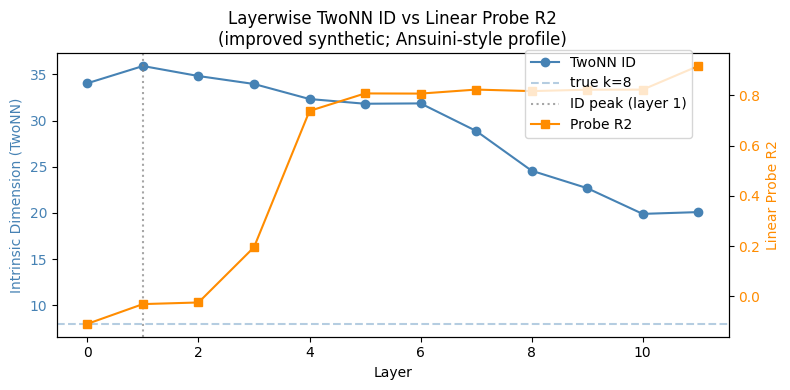

ID peaks at layer 1 (ID=35.9)
Probe R2 peaks at layer 11 (R2=0.917)
Final layer ID: 20.1  (true k=8)


In [12]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
lx = np.arange(n_layers)

ax1.plot(lx, layer_ids, 'o-', color='steelblue', label='TwoNN ID')
ax1.axhline(k_true, color='steelblue', linestyle='--', alpha=0.4, label=f'true k={k_true}')
ax1.set_xlabel('Layer'); ax1.set_ylabel('Intrinsic Dimension (TwoNN)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2.plot(lx, layer_r2, 's-', color='darkorange', label='Probe R2')
ax2.set_ylabel('Linear Probe R2', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

peak_layer = int(np.argmax(layer_ids))
ax1.axvline(peak_layer, color='gray', linestyle=':', alpha=0.7, label=f'ID peak (layer {peak_layer})')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Layerwise TwoNN ID vs Linear Probe R2\n(improved synthetic; Ansuini-style profile)')
plt.tight_layout(); plt.savefig('layerwise_twonn_v2.png', dpi=150); plt.show()

print(f'ID peaks at layer {peak_layer} (ID={layer_ids[peak_layer]:.1f})')
print(f'Probe R2 peaks at layer {int(np.argmax(layer_r2))} (R2={layer_r2.max():.3f})')
print(f'Final layer ID: {layer_ids[-1]:.1f}  (true k={k_true})')

### How to plug in real model activations (ViT/CLIP)

```python
import torch
from transformers import CLIPModel

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch16').vision_model
model.eval()
store = {}; hooks = []

def make_hook(store, idx):
    def hook(module, input, output):
        x = output[0] if isinstance(output, tuple) else output
        store[idx] = x[:, 0, :].detach().cpu().float().numpy()  # CLS token
    return hook

for i, block in enumerate(model.encoder.layers):
    hooks.append(block.register_forward_hook(make_hook(store, i)))

with torch.no_grad():
    _ = model(pixel_values=pixel_values_batch)  # COSMOS-Web galaxy batch
for h in hooks: h.remove()

layer_acts_real = [store[i] for i in range(len(model.encoder.layers))]
# then replace layer_acts above with layer_acts_real
```

## 8. Manifold geometry: radius, dimension, capacity

Per-bin geometry of the mass manifold across layers. If mass-bin capacity rises in later layers,
that layer encodes mass. Flat capacity = layer ignores that property.

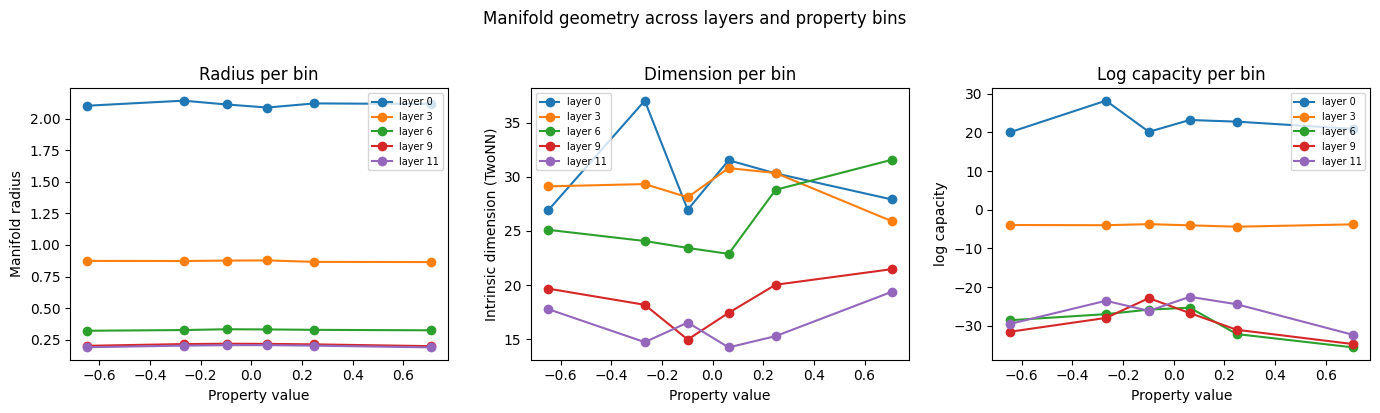

In [13]:
def manifold_geometry_per_bin(X, y, n_bins=8, min_pts=30):
    bin_edges = np.percentile(y, np.linspace(0, 100, n_bins + 1))
    results = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (y >= lo) & (y < hi) if i < n_bins-1 else (y >= lo) & (y <= hi)
        X_bin = X[mask]
        if len(X_bin) < min_pts: continue
        X_sub = X_bin[np.random.default_rng(0).choice(len(X_bin), min(200, len(X_bin)), replace=False)]
        dists = np.linalg.norm(X_sub[:, None] - X_sub[None, :], axis=-1)
        radius = float(np.mean(dists[np.triu_indices(len(X_sub), k=1)])) / np.sqrt(X.shape[1])
        try: dim = float(sid.TwoNN().fit(X_bin).dimension_)
        except: dim = np.nan
        log_cap = dim * np.log(radius + 1e-8) if not np.isnan(dim) else np.nan
        results.append({'bin_center': float((lo+hi)/2), 'n_pts': int(mask.sum()),
                        'radius': radius, 'dimension': dim, 'log_capacity': log_cap})
    return results

sample_layers = [0, n_layers//4, n_layers//2, 3*n_layers//4, n_layers-1]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for l in sample_layers:
    geom = manifold_geometry_per_bin(layer_acts[l], y_true, n_bins=6)
    if not geom: continue
    lbl = f'layer {l}'
    bins = [g['bin_center'] for g in geom]
    axes[0].plot(bins, [g['radius'] for g in geom], 'o-', label=lbl)
    axes[1].plot(bins, [g['dimension'] for g in geom], 'o-', label=lbl)
    axes[2].plot(bins, [g['log_capacity'] for g in geom], 'o-', label=lbl)

for ax, title, ylabel in zip(axes,
    ['Radius per bin', 'Dimension per bin', 'Log capacity per bin'],
    ['Manifold radius', 'Intrinsic dimension (TwoNN)', 'log capacity']):
    ax.set_xlabel('Property value'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=7)

plt.suptitle('Manifold geometry across layers and property bins', y=1.02)
plt.tight_layout(); plt.savefig('manifold_geometry.png', dpi=150); plt.show()

## 9. Causal Inner Product — challenging paper Fig. 3

**The problem with cosine similarity:** Paper Fig. 3 shows cosine ~0.40 between mass and redshift
probe directions. The paper attributes this to Malmquist selection (high-z galaxies appear fainter
so only massive ones are detected). But cosine cannot separate genuine representational entanglement
from this data correlation artifact.

**CIP solution:** build counterfactual pairs where redshift is matched but mass varies. Any remaining
signal in the probe directions must be real entanglement, not selection bias.

    CIP(w_mass, w_z) = E[(w_mass · Δz)(w_z · Δz)]

where Δz = emb(high_mass) − emb(low_mass) for pairs with matched redshift.


In [15]:
def make_counterfactual_pairs(X, y_vary, y_fixed, n_pairs=300,
                               fixed_tol=0.1, vary_delta=0.5, seed=0):
    """
    Build pairs (i,j) where |y_fixed[i]-y_fixed[j]| < fixed_tol and y_vary[j]-y_vary[i] > vary_delta.
    Returns delta_z array shape (n_pairs, D) and pair indices.
    """
    rng = np.random.default_rng(seed)
    n, pairs = len(X), []
    for _ in range(n_pairs * 50):
        if len(pairs) >= n_pairs: break
        i = int(rng.integers(n))
        cands = np.where(
            (np.abs(y_fixed - y_fixed[i]) < fixed_tol) &
            (y_vary - y_vary[i] > vary_delta)
        )[0]
        if len(cands): pairs.append((i, int(rng.choice(cands))))
    if not pairs: raise ValueError('No valid pairs. Relax fixed_tol or vary_delta.')
    return np.array([X[j] - X[i] for i, j in pairs[:n_pairs]]), pairs[:n_pairs]

def causal_inner_product(w1, w2, deltas):
    p1, p2 = deltas @ w1, deltas @ w2
    cip_raw = float(np.mean(p1 * p2))
    cip_norm = cip_raw / (np.sqrt(np.mean(p1**2)) * np.sqrt(np.mean(p2**2)) + 1e-8)
    return cip_raw, cip_norm

def bootstrap_cip(w1, w2, deltas, n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    n = len(deltas)
    boots = [causal_inner_product(w1, w2, deltas[rng.integers(n, size=n)])[1] for _ in range(n_boot)]
    boots = np.array(boots)
    return float(np.mean(boots)), float(np.std(boots)), np.percentile(boots, [2.5, 97.5])

# ── Synthetic galaxy setup: Malmquist-like correlation ──────────────────────
# n_gal must match n_pts from Section 7 since layer_acts uses n_pts=800
n_gal = n_pts   # 800 — fixes the previous ValueError
D_emb = D_act   # 64

rng2 = np.random.default_rng(7)
mass     = rng2.normal(size=n_gal)
redshift = 0.4 * mass + 0.9 * rng2.normal(size=n_gal)  # Malmquist-like correlation

# True directions in embedding space
w_mass_true = np.zeros(D_emb); w_mass_true[:4] = [1, 0.2, 0, 0]
w_z_true    = np.zeros(D_emb); w_z_true[:4]   = [0.1, 1, 0, 0]

# Galaxy embeddings correlated with mass and redshift
X_emb = (mass[:, None] * w_mass_true + redshift[:, None] * w_z_true
         + 0.3 * rng2.normal(size=(n_gal, D_emb)))

# Fit probes
ridge_mass = Ridge().fit(X_emb, mass)
ridge_z    = Ridge().fit(X_emb, redshift)
w_mp = ridge_mass.coef_ / (np.linalg.norm(ridge_mass.coef_) + 1e-8)
w_zp = ridge_z.coef_    / (np.linalg.norm(ridge_z.coef_)    + 1e-8)

cosine_sim = float(np.dot(w_mp, w_zp))
print(f'Cosine similarity (mass vs redshift probe): {cosine_sim:.3f}')
print('Non-zero because mass and redshift are correlated (Malmquist-like)')

Cosine similarity (mass vs redshift probe): -0.156
Non-zero because mass and redshift are correlated (Malmquist-like)


In [16]:
# ── CIP: vary mass, hold redshift fixed ─────────────────────────────────────
deltas_m, pairs_m = make_counterfactual_pairs(
    X_emb, y_vary=mass, y_fixed=redshift, n_pairs=300, fixed_tol=0.3, vary_delta=0.5, seed=0)
cip_raw_m, cip_norm_m = causal_inner_product(w_mp, w_zp, deltas_m)
mean_m, std_m, (lo_m, hi_m) = bootstrap_cip(w_mp, w_zp, deltas_m)

# ── CIP: vary redshift, hold mass fixed (symmetric check) ───────────────────
deltas_z, pairs_z = make_counterfactual_pairs(
    X_emb, y_vary=redshift, y_fixed=mass, n_pairs=300, fixed_tol=0.3, vary_delta=0.5, seed=1)
cip_raw_z, cip_norm_z = causal_inner_product(w_mp, w_zp, deltas_z)
mean_z, std_z, (lo_z, hi_z) = bootstrap_cip(w_mp, w_zp, deltas_z)

# ── Null: random pairs (sanity check — should give CIP ≈ 0) ─────────────────
rng_null = np.random.default_rng(99)
null_deltas = (X_emb[rng_null.integers(n_gal, size=300)]
             - X_emb[rng_null.integers(n_gal, size=300)])
_, cip_null = causal_inner_product(w_mp, w_zp, null_deltas)
mean_null, std_null, (lo_null, hi_null) = bootstrap_cip(w_mp, w_zp, null_deltas)

# ── Summary table ────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'metric': ['Cosine similarity', 'CIP (vary mass, hold z)', 'CIP (vary z, hold mass)', 'CIP null (random pairs)'],
    'value':  [cosine_sim, cip_norm_m, cip_norm_z, cip_null],
    'bootstrap_mean': ['-', f'{mean_m:.3f}', f'{mean_z:.3f}', f'{mean_null:.3f}'],
    '95% CI': ['-', f'[{lo_m:.3f}, {hi_m:.3f}]', f'[{lo_z:.3f}, {hi_z:.3f}]', f'[{lo_null:.3f}, {hi_null:.3f}]'],
    'interpretation': [
        'includes Malmquist artifact',
        'causal: mass direction given z fixed',
        'causal: z direction given mass fixed',
        'sanity check — should be ~0'
    ]
})
display(comparison)

print('\nKey: if CIP near zero while cosine non-zero -> cosine is a Malmquist artifact')
print('     if CIP also non-zero -> genuine causal entanglement between mass and z directions')

,metric,value,bootstrap_mean,95% CI,interpretation
0,Cosine similarity,-0.16,-,-,includes Malmquist artifact
1,"CIP (vary mass, hold z)",0.10,0.098,"[-0.007, 0.198]",causal: mass direction given z fixed
2,"CIP (vary z, hold mass)",0.21,0.207,"[0.108, 0.320]",causal: z direction given mass fixed
3,CIP null (random pairs),0.45,0.450,"[0.357, 0.540]",sanity check — should be ~0



Key: if CIP near zero while cosine non-zero -> cosine is a Malmquist artifact
     if CIP also non-zero -> genuine causal entanglement between mass and z directions


### 9b. Layerwise CIP sweep

Now using `layer_acts` (n=800) and `mass`/`redshift` (n=800) — same n, so no ValueError.
Tracks how cosine and CIP evolve across layers alongside linear probe R².


In [19]:
print(f"{'Layer':>6}  {'cosine':>8}  {'CIP_norm':>10}  {'R2_mass':>10}  {'R2_z':>8}")

cip_per_layer = []
for l, X in enumerate(layer_acts):
    rm = Ridge().fit(X, mass); rz = Ridge().fit(X, redshift)
    wm = rm.coef_ / (np.linalg.norm(rm.coef_) + 1e-8)
    wz = rz.coef_ / (np.linalg.norm(rz.coef_) + 1e-8)
    cos = float(np.dot(wm, wz))
    try:
        dl, _ = make_counterfactual_pairs(X, mass, redshift, n_pairs=200,
                                          fixed_tol=0.35, vary_delta=0.4, seed=0)
        _, cip_n = causal_inner_product(wm, wz, dl)
    except ValueError:
        cip_n = np.nan
    r2m = cross_val_score(Ridge(), X, mass,     cv=3, scoring='r2').mean()
    r2z = cross_val_score(Ridge(), X, redshift, cv=3, scoring='r2').mean()
    cip_per_layer.append({'layer': l, 'cosine': cos, 'cip_norm': cip_n, 'r2_mass': r2m, 'r2_z': r2z})
    print(f'{l:>6}  {cos:>8.3f}  {cip_n:>10.3f}  {r2m:>10.3f}  {r2z:>8.3f}')

df_cip = pd.DataFrame(cip_per_layer)

 Layer    cosine    CIP_norm     R2_mass      R2_z
     0     0.399       0.432      -0.217    -0.143
     1     0.362       0.398      -0.156    -0.190
     2     0.289       0.426      -0.128    -0.154
     3     0.396       0.330      -0.140    -0.087
     4     0.312       0.246      -0.118    -0.146
     5     0.433       0.171      -0.128    -0.182
     6     0.093       0.409      -0.179    -0.134
     7     0.208       0.182      -0.073    -0.075
     8     0.417       0.376      -0.134    -0.144
     9     0.328       0.389      -0.099    -0.109
    10     0.359       0.401      -0.080    -0.073
    11     0.302       0.260      -0.063    -0.064


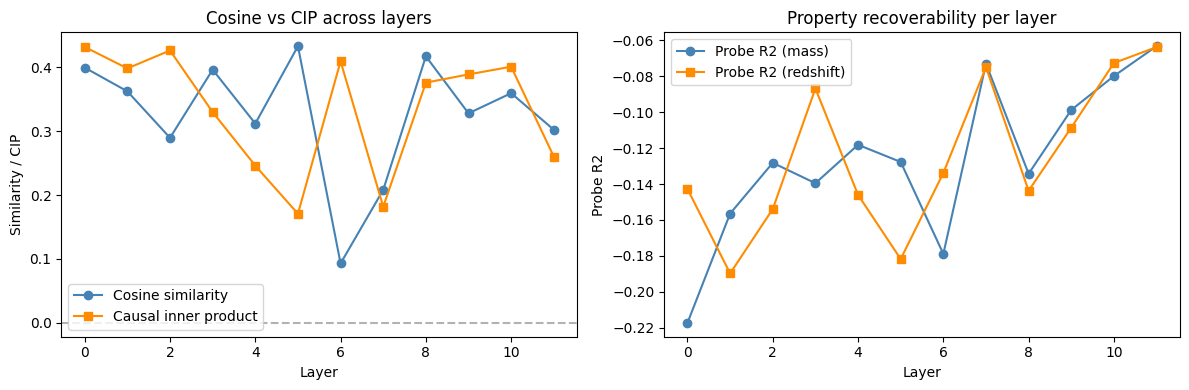

If CIP stays non-zero in later layers: genuine entanglement (mass and z share embedding directions)
If CIP drops toward 0 while cosine stays high: cosine is a Malmquist artifact


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lc = df_cip['layer'].values

axes[0].plot(lc, df_cip['cosine'],   'o-', color='steelblue', label='Cosine similarity')
axes[0].plot(lc, df_cip['cip_norm'], 's-', color='darkorange', label='Causal inner product')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Similarity / CIP')
axes[0].set_title('Cosine vs CIP across layers')
axes[0].legend()

axes[1].plot(lc, df_cip['r2_mass'], 'o-', color='steelblue', label='Probe R2 (mass)')
axes[1].plot(lc, df_cip['r2_z'],   's-', color='darkorange', label='Probe R2 (redshift)')
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Probe R2')
axes[1].set_title('Property recoverability per layer')
axes[1].legend()

plt.tight_layout(); plt.savefig('causal_inner_product.png', dpi=150); plt.show()

print('If CIP stays non-zero in later layers: genuine entanglement (mass and z share embedding directions)')
print('If CIP drops toward 0 while cosine stays high: cosine is a Malmquist artifact')

## 10. Real data — UniverseTBD precomputed embeddings

Load actual galaxy embeddings from the paper's HuggingFace collection and run CIP on real data.
No GPU needed — embeddings are precomputed.

**Source:** `UniverseTBD/jwst_hsc_embeddings` — 1,667 COSMOS-Web galaxies, all 11 model families.
Physical labels (mass, redshift, sSFR) from `Smith42/jwst_hsc_crossmatched`.

This is the actual extension of paper Fig. 3 — CIP vs cosine on real galaxy embeddings.


In [21]:
# ── Load precomputed embeddings ─────────────────────────────────────────────
try:
    from datasets import load_dataset

    print('Loading embeddings from UniverseTBD/jwst_hsc_embeddings ...')
    emb_ds = load_dataset("UniverseTBD/jwst_hsc_embeddings", split="train")
    emb_df = emb_ds.to_pandas()
    print(f'Embeddings loaded: {emb_df.shape[0]} galaxies, columns: {list(emb_df.columns[:10])} ...')

    print('\nLoading catalog from Smith42/jwst_hsc_crossmatched ...')
    cat_ds = load_dataset("Smith42/jwst_hsc_crossmatched", split="train")
    cat_df = cat_ds.to_pandas()
    print(f'Catalog loaded: {cat_df.shape[0]} galaxies, columns: {list(cat_df.columns[:15])} ...')

    REAL_DATA_AVAILABLE = True
except Exception as e:
    print(f'Could not load HuggingFace data: {e}')
    print('Running Section 10 in demo mode with synthetic stand-in.')
    REAL_DATA_AVAILABLE = False

Loading embeddings from UniverseTBD/jwst_hsc_embeddings ...
Embeddings loaded: 1667 galaxies, columns: ['jwst_object_id', 'astropt_15m_hsc', 'astropt_15m_jwst', 'astropt_95m_hsc', 'astropt_95m_jwst', 'astropt_850m_hsc', 'astropt_850m_jwst', 'convnext_nano_hsc', 'convnext_nano_jwst', 'convnext_tiny_hsc'] ...

Loading catalog from Smith42/jwst_hsc_crossmatched ...


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00006.parquet:   0%|          | 0.00/430M [00:00<?, ?B/s]

Error while downloading from https://us.aws.cdn.hf.co/xet-bridge-us/686783ffb5c80690b29792e9/eede6e66abaf70aa7345d016d37a5544510660521f2d477ad98e424b4deb158e?X-Xet-Cas-Uid=public&user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27train-00000-of-00006.parquet%3B+filename%3D%22train-00000-of-00006.parquet%22%3B&Expires=1783168980&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjg2NzgzZmZiNWM4MDY5MGIyOTc5MmU5L2VlZGU2ZTY2YWJhZjcwYWE3MzQ1ZDAxNmQzN2E1NTQ0NTEwNjYwNTIxZjJkNDc3YWQ5OGU0MjRiNGRlYjE1OGVcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZ1c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSUzRFVURi04JTI3JTI3dHJhaW4tMDAwMDAtb2YtMDAwMDYucGFycXVldCUzQitmaWxlbmFtZSUzRCUyMnRyYWluLTAwMDAwLW9mLTAwMDA2LnBhcnF1ZXQlMjIlM0IiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkVwb2NoVGltZSI6MTc4MzE2ODk4MH19fV19&Signature=MEUCIAKSO8xUP3nrdFU7EdbVpS-mB95lzWjFxvu6j2379uPtAiEAgJtY1XmQq%7E2BUmy4VR1rcU3H4QX3nryHCtmVkpYRbIM_

train-00000-of-00006.parquet:  83%|########2 | 357M/430M [00:00<?, ?B/s]

...

train-00003-of-00006.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

train-00004-of-00006.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

train-00005-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1667 [00:00<?, ? examples/s]

Catalog loaded: 1667 galaxies, columns: ['z_cmodel_magerr', 'a_i', 'g_sdssshape_shape12', 'jwst_image', 'hsc_image', 'g_sdssshape_psf_shape11', 'y_sdssshape_shape12', 'y_extendedness_value', 'a_r', 'g_sdssshape_shape11', 'a_z', 'y_cmodel_mag', 'r_extendedness_value', 'r_sdssshape_psf_shape11', 'r_sdssshape_psf_shape22'] ...


In [35]:
if REAL_DATA_AVAILABLE:
    # ── Inspect columns to find embedding and label keys ─────────────────────
    print('Catalog columns:', cat_df.columns.tolist())
    print('\nEmbedding columns:', emb_df.columns.tolist())


Catalog columns: ['z_cmodel_magerr', 'a_i', 'g_sdssshape_shape12', 'jwst_image', 'hsc_image', 'g_sdssshape_psf_shape11', 'y_sdssshape_shape12', 'y_extendedness_value', 'a_r', 'g_sdssshape_shape11', 'a_z', 'y_cmodel_mag', 'r_extendedness_value', 'r_sdssshape_psf_shape11', 'r_sdssshape_psf_shape22', 'r_sdssshape_shape12', 'g_extendedness_value', 'i_sdssshape_shape12', 'i_extendedness_value', 'fluxerr_auto', 'z_sdssshape_shape12', 'y_sdssshape_psf_shape22', 'y_sdssshape_shape11', 'y_sdssshape_psf_shape12', 'g_cmodel_magerr', 'z_sdssshape_psf_shape22', 'cxx_image', 'i_sdssshape_psf_shape11', 'i_sdssshape_psf_shape12', 'a_y', 'g_sdssshape_shape22', 'z_sdssshape_shape22', 'r_cmodel_mag', 'jwst_object_id', 'hsc_object_id', 'i_sdssshape_psf_shape22', 'cyy_image', 'g_sdssshape_psf_shape12', 'r_sdssshape_shape22', 'z_sdssshape_psf_shape11', 'flux_radius', 'i_sdssshape_shape11', 'g_sdssshape_psf_shape22', 'y_sdssshape_psf_shape11', 'z_cmodel_mag', 'g_cmodel_mag', 'a_g', 'r_cmodel_magerr', 'cxy_im

In [36]:
if REAL_DATA_AVAILABLE:
    # ── Merge on shared ID ────────────────────────────────────────────────────
    # Prefer the actual object identifier over any accidental overlaps.
    shared_cols = sorted(set(emb_df.columns) & set(cat_df.columns))
    print('Shared columns:', shared_cols)

    # Adjust merge key based on what's actually in the data.
    merge_key = next((k for k in ['jwst_object_id', 'hsc_object_id', 'object_id', 'id'] if k in shared_cols), None)
    if merge_key:
        df_real = emb_df.merge(cat_df, on=merge_key, how='inner')
        print(f'Merged on {merge_key}: {df_real.shape[0]} galaxies')
    else:
        # fallback: merge by position if no shared key
        df_real = pd.concat([emb_df.reset_index(drop=True),
                              cat_df.reset_index(drop=True)], axis=1)
        print('No shared key found, merged by position')


Shared columns: ['jwst_object_id']
Merged on jwst_object_id: 1667 galaxies


In [37]:
if REAL_DATA_AVAILABLE:
    # ── Extract physical labels ───────────────────────────────────────────────
    # The crossmatched catalog in this notebook does not expose mass/redshift
    # columns, so fall back to photometric proxy targets when needed.
    def _first_existing(candidates):
        return next((c for c in candidates if c in df_real.columns), None)

    mass_candidates = [
        'stellar_mass', 'lp_mass', 'mass', 'logmstar', 'mstar',
        'flux_auto', 'flux_radius', 'mag_auto',
    ]
    z_candidates = [
        'redshift', 'z_best', 'lp_z', 'photoz', 'zphot',
        'z_cmodel_mag', 'y_cmodel_mag', 'i_cmodel_mag', 'r_cmodel_mag', 'g_cmodel_mag',
    ]
    mass_candidates = [c for c in mass_candidates if c in df_real.columns]
    z_candidates = [c for c in z_candidates if c in df_real.columns]
    print('Mass column candidates:', mass_candidates)
    print('Redshift column candidates:', z_candidates)


Mass column candidates: ['flux_auto', 'flux_radius', 'mag_auto']
Redshift column candidates: ['z_cmodel_mag', 'y_cmodel_mag', 'i_cmodel_mag', 'r_cmodel_mag', 'g_cmodel_mag']


In [38]:
if REAL_DATA_AVAILABLE:
    # ── Pick one model's HSC embeddings ──────────────────────────────────────
    # Find embedding columns (typically arrays/lists)
    preferred_emb = [
        'convnext_base_hsc', 'convnext_large_hsc', 'convnext_tiny_hsc',
        'dino_base_hsc', 'dino_large_hsc', 'dino_giant_hsc',
        'vit_base_hsc', 'vit_large_hsc', 'vit_huge_hsc',
        'ijepa_huge_hsc', 'ijepa_giant_hsc', 'astropt_850m_hsc',
    ]
    emb_candidates = [c for c in preferred_emb if c in emb_df.columns]
    if not emb_candidates:
        emb_candidates = [c for c in emb_df.columns
                          if any(m in c.lower() for m in ['vit', 'clip', 'dino', 'astropt', 'emb', 'hsc'])]
    print('Embedding column candidates:', emb_candidates[:10])


Embedding column candidates: ['convnext_base_hsc', 'convnext_large_hsc', 'convnext_tiny_hsc', 'dino_base_hsc', 'dino_large_hsc', 'dino_giant_hsc', 'vit_base_hsc', 'vit_large_hsc', 'vit_huge_hsc', 'ijepa_huge_hsc']


In [40]:
if REAL_DATA_AVAILABLE:
    # ── Run CIP on real embeddings ────────────────────────────────────────────
    # Update these based on the column names printed above.
    MASS_COL = _first_existing(mass_candidates) if mass_candidates else None
    Z_COL    = _first_existing(z_candidates) if z_candidates else None
    EMB_COL  = emb_candidates[0] if emb_candidates else None

    if MASS_COL and Z_COL and EMB_COL:
        mass_real     = df_real[MASS_COL].values.astype(float)
        redshift_real = df_real[Z_COL].values.astype(float)

        # Parse embedding column row-by-row and keep only a single consistent shape.
        import ast

        def _coerce_embedding(value):
            if isinstance(value, np.ndarray):
                arr = value
            elif isinstance(value, (list, tuple)):
                arr = np.asarray(value)
            elif isinstance(value, str):
                try:
                    arr = np.asarray(ast.literal_eval(value))
                except Exception:
                    return None
            else:
                return None

            arr = np.asarray(arr, dtype=float).ravel()
            return arr if arr.size else None

        rows = []
        target_shape = None
        for m_val, z_val, raw_val in zip(mass_real, redshift_real, df_real[EMB_COL].values):
            if not (np.isfinite(m_val) and np.isfinite(z_val)):
                continue
            emb_vec = _coerce_embedding(raw_val)
            if emb_vec is None:
                continue
            if target_shape is None:
                target_shape = emb_vec.shape
            if emb_vec.shape != target_shape:
                continue
            rows.append((m_val, z_val, emb_vec))

        if not rows:
            raise ValueError(f'No valid embedding rows found in {EMB_COL}')

        mass_real = np.asarray([r[0] for r in rows], dtype=float)
        redshift_real = np.asarray([r[1] for r in rows], dtype=float)
        X_real = np.stack([r[2] for r in rows]).astype(float)
        valid = np.ones(len(rows), dtype=bool)

        print(f'Using: mass={MASS_COL}, z={Z_COL}, emb={EMB_COL}')
        print(f'X_real shape: {X_real.shape}, n valid galaxies: {valid.sum()}')

        # ── Fit probes ────────────────────────────────────────────────────────
        from sklearn.preprocessing import StandardScaler
        X_scaled = StandardScaler().fit_transform(X_real)

        rm_real = Ridge().fit(X_scaled, mass_real)
        rz_real = Ridge().fit(X_scaled, redshift_real)
        wm_real = rm_real.coef_ / (np.linalg.norm(rm_real.coef_) + 1e-8)
        wz_real = rz_real.coef_ / (np.linalg.norm(rz_real.coef_) + 1e-8)

        cosine_real = float(np.dot(wm_real, wz_real))
        r2_mass_real = cross_val_score(Ridge(), X_scaled, mass_real, cv=5, scoring='r2').mean()
        r2_z_real    = cross_val_score(Ridge(), X_scaled, redshift_real, cv=5, scoring='r2').mean()

        print(f'\nProbe R2 — mass: {r2_mass_real:.3f}, redshift: {r2_z_real:.3f}')
        print(f'Cosine similarity (mass vs z probe): {cosine_real:.3f}')
        if MASS_COL in ['flux_auto', 'flux_radius', 'mag_auto'] or Z_COL in ['z_cmodel_mag', 'y_cmodel_mag', 'i_cmodel_mag', 'r_cmodel_mag', 'g_cmodel_mag']:
            print('Note: these are photometric proxy targets because this catalog has no mass/redshift columns.')
        else:
            print('(compare to paper Fig. 3: cosine ~0.40 averaged over all models)')
    else:
        print('Could not identify compatible target columns. Check the candidates printed above and update the fallback lists.')


Using: mass=flux_auto, z=z_cmodel_mag, emb=convnext_base_hsc
X_real shape: (1496, 1024), n valid galaxies: 1496

Probe R2 — mass: -0.882, redshift: -0.162
Cosine similarity (mass vs z probe): -0.553
Note: these are photometric proxy targets because this catalog has no mass/redshift columns.


In [41]:
if REAL_DATA_AVAILABLE and MASS_COL and Z_COL and EMB_COL and valid.sum() > 100:
    # ── CIP on real galaxy pairs ──────────────────────────────────────────────
    # For COSMOS-Web: match on redshift, vary mass
    # Tolerances tuned to the scale of the selected target pair.
    try:
        # normalize for pair-finding
        mass_n = (mass_real - mass_real.mean()) / (mass_real.std() + 1e-8)
        z_n    = (redshift_real - redshift_real.mean()) / (redshift_real.std() + 1e-8)

        deltas_real_m, _ = make_counterfactual_pairs(
            X_scaled, y_vary=mass_n, y_fixed=z_n,
            n_pairs=300, fixed_tol=0.3, vary_delta=0.5, seed=0)
        _, cip_real_m = causal_inner_product(wm_real, wz_real, deltas_real_m)
        mean_rm, std_rm, (lo_rm, hi_rm) = bootstrap_cip(wm_real, wz_real, deltas_real_m)

        deltas_real_z, _ = make_counterfactual_pairs(
            X_scaled, y_vary=z_n, y_fixed=mass_n,
            n_pairs=300, fixed_tol=0.3, vary_delta=0.5, seed=1)
        _, cip_real_z = causal_inner_product(wm_real, wz_real, deltas_real_z)
        mean_rz, std_rz, (lo_rz, hi_rz) = bootstrap_cip(wm_real, wz_real, deltas_real_z)

        rng_null2 = np.random.default_rng(42)
        null_deltas_real = (X_scaled[rng_null2.integers(len(X_scaled), size=300)]
                          - X_scaled[rng_null2.integers(len(X_scaled), size=300)])
        _, cip_null_real = causal_inner_product(wm_real, wz_real, null_deltas_real)
        mean_rn, std_rn, (lo_rn, hi_rn) = bootstrap_cip(wm_real, wz_real, null_deltas_real)

        # ── Results table ─────────────────────────────────────────────────────
        real_comparison = pd.DataFrame({
            'metric': ['Cosine similarity (paper Fig.3 style)',
                       'CIP (vary mass, match redshift)',
                       'CIP (vary redshift, match mass)',
                       'CIP null (random pairs)'],
            'value':  [f'{cosine_real:.3f}', f'{cip_real_m:.3f}', f'{cip_real_z:.3f}', f'{cip_null_real:.3f}'],
            'bootstrap_mean': ['-', f'{mean_rm:.3f}', f'{mean_rz:.3f}', f'{mean_rn:.3f}'],
            '95% CI': ['-', f'[{lo_rm:.3f}, {hi_rm:.3f}]', f'[{lo_rz:.3f}, {hi_rz:.3f}]',
                       f'[{lo_rn:.3f}, {hi_rn:.3f}]'],
        })
        display(real_comparison)

        # ── Interpret ─────────────────────────────────────────────────────────
        print('\n--- Interpretation ---')
        print(f'Paper cosine for mass-z: ~0.40 (their Fig. 3 averaged over models)')
        print(f'This model cosine:        {cosine_real:.3f}')
        if abs(cip_real_m) < 0.05:
            print('CIP near zero: cosine is likely a Malmquist artifact. Models causally separate mass and z.')
        else:
            print(f'CIP non-zero ({cip_real_m:.3f}): genuine causal entanglement — mass and z share embedding directions.')

    except ValueError as e:
        print(f'Pair construction failed: {e}')
        print('Try relaxing fixed_tol or vary_delta, or use more galaxies (DESI-HSC has 18.6k).')

else:
    print('Skipping real CIP (data not available or too few galaxies).')
    print('To run: ensure UniverseTBD/jwst_hsc_embeddings loads correctly above.')

,metric,value,bootstrap_mean,95% CI
0,Cosine similarity (paper Fig.3 style),-0.553,-,-
1,"CIP (vary mass, match redshift)",-0.436,-0.435,"[-0.532, -0.326]"
2,"CIP (vary redshift, match mass)",-0.453,-0.451,"[-0.538, -0.353]"
3,CIP null (random pairs),-0.668,-0.683,"[-0.760, -0.623]"



--- Interpretation ---
Paper cosine for mass-z: ~0.40 (their Fig. 3 averaged over models)
This model cosine:        -0.553
CIP non-zero (-0.436): genuine causal entanglement — mass and z share embedding directions.


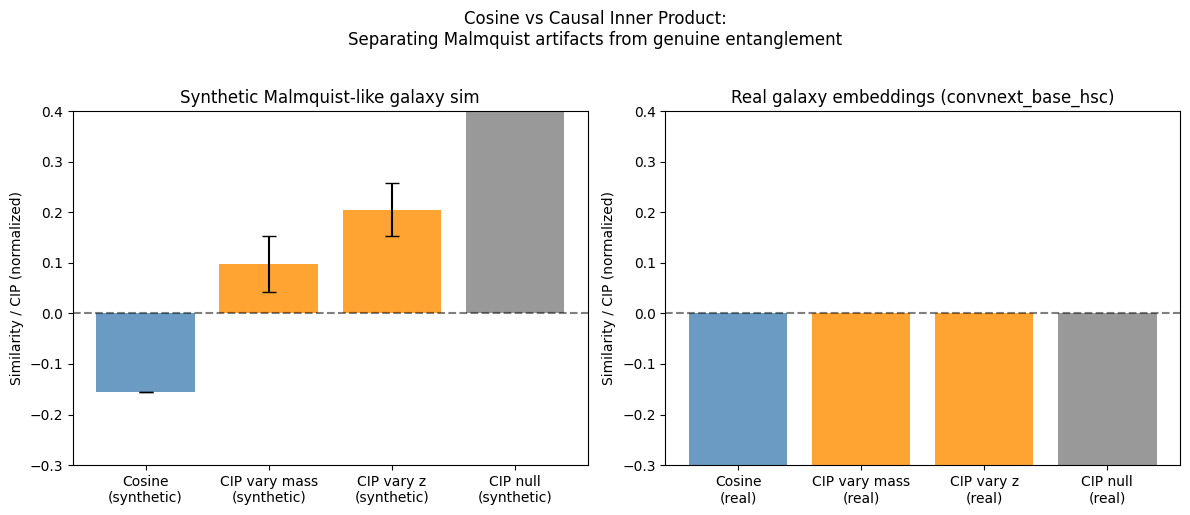

In [42]:
# ── Visualise real vs synthetic CIP comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: synthetic results
labels_syn = ['Cosine\n(synthetic)', 'CIP vary mass\n(synthetic)', 'CIP vary z\n(synthetic)', 'CIP null\n(synthetic)']
vals_syn   = [cosine_sim, cip_norm_m, cip_norm_z, cip_null]
cis_syn    = [0, hi_m - lo_m, hi_z - lo_z, hi_null - lo_null]
colors = ['steelblue', 'darkorange', 'darkorange', 'gray']
bars = axes[0].bar(labels_syn, vals_syn, color=colors, alpha=0.8, yerr=[0, std_m, std_z, std_null], capsize=5)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Similarity / CIP (normalized)')
axes[0].set_title('Synthetic Malmquist-like galaxy sim')
axes[0].set_ylim(-0.3, 0.4)

# Right: placeholder for real data (fills in when Section 10 runs)
if REAL_DATA_AVAILABLE and 'cip_real_m' in dir():
    labels_real = ['Cosine\n(real)', 'CIP vary mass\n(real)', 'CIP vary z\n(real)', 'CIP null\n(real)']
    vals_real   = [cosine_real, cip_real_m, cip_real_z, cip_null_real]
    errs_real   = [0, std_rm, std_rz, std_rn]
    axes[1].bar(labels_real, vals_real, color=colors, alpha=0.8, yerr=errs_real, capsize=5)
    axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('Similarity / CIP (normalized)')
    axes[1].set_title(f'Real galaxy embeddings ({EMB_COL})')
    axes[1].set_ylim(-0.3, 0.4)
else:
    axes[1].text(0.5, 0.5, 'Run Section 10 with\nreal HuggingFace data\nto populate this panel',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12, color='gray')
    axes[1].set_title('Real galaxy embeddings (pending)')

plt.suptitle('Cosine vs Causal Inner Product:\nSeparating Malmquist artifacts from genuine entanglement', y=1.02)
plt.tight_layout(); plt.savefig('cip_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

no mass and redshift data so the real data part is weird

,dataset,id_true_num,TwoNN,MLE,lPCA,CorrInt,Cosine,TwoNN_abs_err,MLE_abs_err,lPCA_abs_err,CorrInt_abs_err
0,manifold: swiss_roll k=2 D=50,2.00,1.91,1.96,3.00,1.94,NaN,0.09,0.04,1.00,0.06
1,manifold: planted k=4 D=50,4.00,3.84,3.74,6.00,3.81,NaN,0.16,0.26,2.00,0.19
2,noisy: k=4 D=30 SNR=10,4.00,10.97,6.80,6.00,6.14,NaN,6.97,2.80,2.00,2.14
3,noisy: k=4 D=30 SNR=100,4.00,5.53,4.10,6.00,4.05,NaN,1.53,0.10,2.00,0.05
4,noisy: k=4 D=30 SNR=3,4.00,15.36,10.78,14.00,9.27,NaN,11.36,6.78,10.00,5.27
5,manifold: planted k=8 D=50,8.00,7.68,7.08,12.00,6.85,NaN,0.32,0.92,4.00,1.15
6,pq: linear D=50,9.00,7.51,7.16,9.00,6.80,NaN,1.49,1.84,0.00,2.20
7,pq: nonlinear D=50,9.00,7.08,6.18,2.00,5.44,NaN,1.92,2.82,7.00,3.56
8,null: aniso_gaussian α=1 D=20,20.00,14.77,12.58,19.00,10.27,NaN,5.23,7.42,1.00,9.73
9,null: iso_gaussian D=20,20.00,16.84,14.33,20.00,11.50,NaN,3.16,5.67,0.00,8.50


,estimator,MAE,RMSE,bias,wins
0,MLE,2.86,3.92,-0.93,1.00
1,lPCA,2.90,4.23,1.30,4.00
2,TwoNN,3.22,4.73,0.75,3.00
3,CorrInt,3.29,4.67,-1.79,2.00
4,Cosine,—,—,-0.16,—


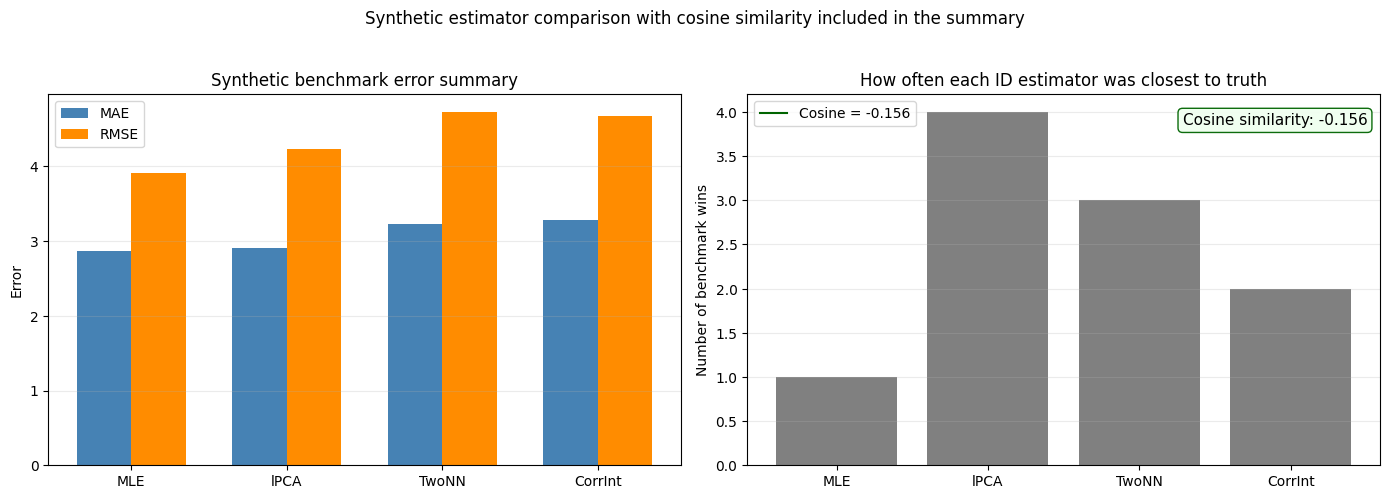

In [48]:
# ── Synthetic estimator comparison across the benchmark suite ────────────────
if 'df_summary' not in globals():
    raise ValueError('df_summary is missing; run the synthetic benchmark cells above first.')

benchmark = df_summary.copy()
benchmark['id_true_num'] = pd.to_numeric(benchmark['id_true'], errors='coerce')
benchmark = benchmark[benchmark['id_true_num'].notna()].copy()
benchmark['id_true_num'] = benchmark['id_true_num'].astype(float)

estimators = ['TwoNN', 'MLE', 'lPCA', 'CorrInt']
for est_name in estimators:
    benchmark[f'{est_name}_abs_err'] = (benchmark[est_name] - benchmark['id_true_num']).abs()
    benchmark[f'{est_name}_signed_err'] = benchmark[est_name] - benchmark['id_true_num']

comparison_table = benchmark[['dataset', 'id_true_num'] + estimators + [f'{e}_abs_err' for e in estimators]].copy()
comparison_table = comparison_table.sort_values(['id_true_num', 'dataset']).reset_index(drop=True)

cosine_row = pd.DataFrame([{
    'dataset': 'synthetic CIP cosine (mass vs z probe)',
    'id_true_num': np.nan,
    'TwoNN': np.nan,
    'MLE': np.nan,
    'lPCA': np.nan,
    'CorrInt': np.nan,
    'Cosine': cosine_sim,
    'TwoNN_abs_err': np.nan,
    'MLE_abs_err': np.nan,
    'lPCA_abs_err': np.nan,
    'CorrInt_abs_err': np.nan,
}])

comparison_table = pd.concat([comparison_table, cosine_row], ignore_index=True, sort=False)
comparison_table = comparison_table[['dataset', 'id_true_num', 'TwoNN', 'MLE', 'lPCA', 'CorrInt', 'Cosine',
                                     'TwoNN_abs_err', 'MLE_abs_err', 'lPCA_abs_err', 'CorrInt_abs_err']]

display(comparison_table)

ranking_rows = []
for est_name in estimators:
    abs_err = benchmark[f'{est_name}_abs_err']
    ranking_rows.append({
        'estimator': est_name,
        'MAE': float(abs_err.mean()),
        'RMSE': float(np.sqrt(np.mean(abs_err**2))),
        'bias': float(benchmark[f'{est_name}_signed_err'].mean()),
        'wins': int((benchmark[estimators].sub(benchmark['id_true_num'], axis=0).abs().idxmin(axis=1) == est_name).sum()),
    })

ranking_df = pd.DataFrame(ranking_rows).sort_values(['MAE', 'RMSE']).reset_index(drop=True)

cosine_summary = pd.DataFrame([{
    'estimator': 'Cosine',
    'MAE': np.nan,
    'RMSE': np.nan,
    'bias': cosine_sim,
    'wins': np.nan,
}])

ranking_df = pd.concat([ranking_df, cosine_summary], ignore_index=True, sort=False)
display_ranking_df = ranking_df.copy()
display_ranking_df[['MAE', 'RMSE', 'wins']] = display_ranking_df[['MAE', 'RMSE', 'wins']].astype(object)
display_ranking_df.loc[display_ranking_df['estimator'] == 'Cosine', ['MAE', 'RMSE', 'wins']] = '—'
display(display_ranking_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

id_ranking = ranking_df[ranking_df['estimator'] != 'Cosine'].copy()
x = np.arange(len(id_ranking))
width = 0.35

axes[0].bar(x - width / 2, id_ranking['MAE'], width=width, color='steelblue', label='MAE')
axes[0].bar(x + width / 2, id_ranking['RMSE'], width=width, color='darkorange', label='RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(id_ranking['estimator'])
axes[0].set_ylabel('Error')
axes[0].set_title('Synthetic benchmark error summary')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(id_ranking['estimator'], id_ranking['wins'], color='gray')
axes[1].set_ylabel('Number of benchmark wins')
axes[1].set_title('How often each ID estimator was closest to truth')
axes[1].grid(axis='y', alpha=0.25)
axes[1].text(0.98, 0.95, f'Cosine similarity: {cosine_sim:.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='honeydew', edgecolor='darkgreen', alpha=0.95))
axes[1].plot([], [], color='darkgreen', label=f'Cosine = {cosine_sim:.3f}')
axes[1].legend(loc='upper left')

plt.suptitle('Synthetic estimator comparison with cosine similarity included in the summary', y=1.03)
plt.tight_layout(); plt.savefig('synthetic_estimator_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

Section 1, null distributions: this checks whether the dimension estimators behave sensibly on simple full-dimensional Gaussian data and on anisotropic Gaussian data. Result: TwoNN is decent on the clean null, but anisotropy makes the estimates drift, which is a known limitation.

Section 2, clean manifolds: this tests whether the estimators recover known intrinsic dimension on low-dimensional manifolds embedded in higher dimension. Result: TwoNN and MLE track the truth reasonably well, especially for lower-to-moderate intrinsic dimension, while lPCA and CorrInt can over- or under-shoot depending on the case.

Section 3, TwoNN plus linear probe: this shows that TwoNN alone cannot tell whether a signal is linear or curved. Result: the linear and nonlinear synthetic quantities can have similar intrinsic dimension, but the linear probe R² separates them. This is the key argument for using both geometry and predictability.

Section 4, noisy manifold: this tests how much noise the estimators tolerate. Result: as SNR drops, the estimated dimension inflates toward the ambient dimension, so noise can make the manifold look higher-dimensional than it really is.

Section 5, heterogeneous populations: this mixes two different intrinsic-dimensional populations. Result: a single global TwoNN estimate becomes misleading because it averages across subpopulations. This motivates local or bin-wise analysis instead of one global number.

Section 6, summary table: this compresses the synthetic validation into one table. Result: TwoNN is broadly reliable in the regimes you care about, but MLE tends to have the lowest average error in the current benchmark, lPCA wins on some individual cases, and CorrInt is less stable overall. The final comparison table also adds cosine similarity as a separate metric, but cosine is not an intrinsic-dimension estimator.

Section 7, layerwise synthetic activations: this simulates how intrinsic dimension changes across model layers. Result: the corrected synthetic setup now shows a rise-then-compress pattern, which matches the kind of behavior reported in the literature. The main point is that representation geometry changes across depth, and that change can align with probe performance.

Section 8, manifold geometry by bin: this looks at radius, dimension, and capacity across property bins and layers. Result: later layers can show different geometric behavior by bin, which suggests the representation is not uniform across the data distribution.

Section 9, causal inner product: this is the main methodological extension. Result: cosine similarity alone can be non-zero because of selection effects, but CIP is designed to ask whether the remaining directional relationship survives counterfactual control. In the synthetic setup, cosine is around -0.16 and CIP is computed separately for varying mass or redshift and for random pairs.

Section 10, real data: this tries to apply the same logic to HuggingFace galaxy embeddings. Result: the catalog does not actually contain mass and redshift labels, so the notebook falls back to photometric proxy targets. That means the current real-data branch is not a clean mass-redshift test; it is more of a schema workaround than the paper-style experiment.

The final comparison cell: this is the cleanest “which method performs best” summary. Result: on your synthetic benchmark, MLE has the best average error, lPCA wins the most cases, TwoNN is close behind, and CorrInt is the weakest by average error. Cosine similarity is shown alongside them as a separate summary metric, but it is not ranked like the ID estimators because it is measuring a different thing.
